## <h2 style="color: #9983b8;">Import Libraries</h2>

In [65]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

# Plot styling
sns.set_style("whitegrid")
plt.style.use("seaborn-v0_8")

# Display settings
pd.set_option("display.max_columns", None)

print("Libraries imported successfully.")

Libraries imported successfully.


## <h2 style="color: #cb236f;">Load cleaned dataset</h2>

In [66]:
df = pd.read_csv("/Users/laxmigupte/Desktop/Forest-fire-risk-project/data/processed/forestfires_cleaned.csv")
print("Cleaned dataset loaded successfully.")

Cleaned dataset loaded successfully.


## <h2 style="color: #cb236f;">Data Overview</h2>

In [67]:
print("Dataset Shape:", df.shape)

display(df.head())

display(df.describe())

Dataset Shape: (513, 13)


,x_coordinate,y_coordinate,month,day,fine_fuel_moisture_code,duff_moisture_code,drought_code,initial_spread_index,temp,relative_humidity,wind,rain,area
0,7,5,mar,fri,86.2,26.2,94.3,5.1,8.2,51,6.7,0.0,0.0
1,7,4,oct,tue,90.6,35.4,669.1,6.7,18.0,33,0.9,0.0,0.0
2,7,4,oct,sat,90.6,43.7,686.9,6.7,14.6,33,1.3,0.0,0.0
3,8,6,mar,fri,91.7,33.3,77.5,9.0,8.3,97,4.0,0.2,0.0
4,8,6,mar,sun,89.3,51.3,102.2,9.6,11.4,99,1.8,0.0,0.0


,x_coordinate,y_coordinate,fine_fuel_moisture_code,duff_moisture_code,drought_code,initial_spread_index,temp,relative_humidity,wind,rain,area
count,513.000000,513.000000,513.000000,513.000000,513.000000,513.000000,513.000000,513.000000,513.000000,513.000000,513.000000
mean,4.678363,4.300195,90.637427,110.989279,549.155166,9.023587,18.887524,44.348928,4.010526,0.021832,12.891598
std,2.320059,1.230925,5.540920,64.191013,247.724594,4.575543,5.828128,16.358803,1.796613,0.297107,63.892586
min,1.000000,2.000000,18.700000,1.100000,7.900000,0.000000,2.200000,15.000000,0.400000,0.000000,0.000000
25%,3.000000,4.000000,90.200000,68.600000,440.900000,6.400000,15.500000,33.000000,2.700000,0.000000,0.000000
50%,4.000000,4.000000,91.600000,108.300000,664.500000,8.400000,19.300000,42.000000,4.000000,0.000000,0.540000
75%,7.000000,5.000000,92.900000,142.400000,713.900000,11.000000,22.800000,53.000000,4.900000,0.000000,6.570000
max,9.000000,9.000000,96.200000,291.300000,860.600000,56.100000,33.300000,100.000000,9.400000,6.400000,1090.840000


## <h1 style="color: #9983b8;">EXPLORATORY DATA ANALYSIS</h1>

## <h2 style="color: #cb236f;">1. Target Variable Analysis</h2>


## <h4 style="color: #6b9c80;">- Distribution of burned area</h4>

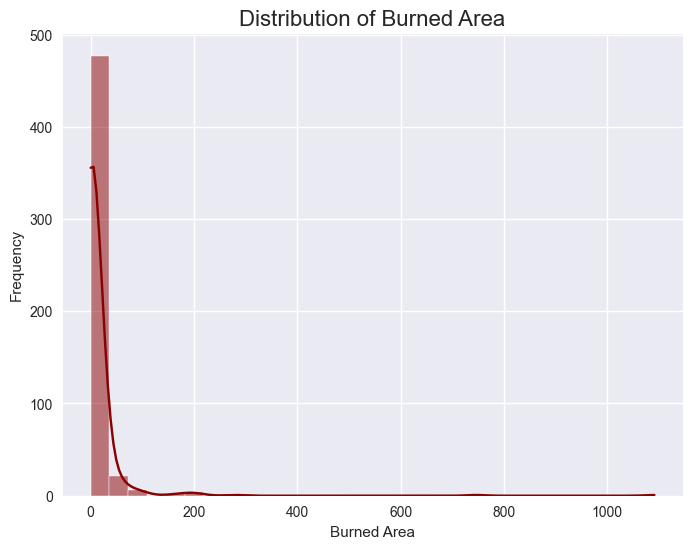

In [68]:
plt.figure(figsize=(8,6))

sns.histplot(
    df["area"],
    bins=30,
    kde=True,
    color="darkred"
)

plt.title("Distribution of Burned Area", fontsize=16)
plt.xlabel("Burned Area")
plt.ylabel("Frequency")

plt.show()

<div style="color:#60b9e5;">

## <h4>Insights: 
</h4> </div>

## <h4 style="color: #6b9c80;">- Log transformation of burned area</h4>

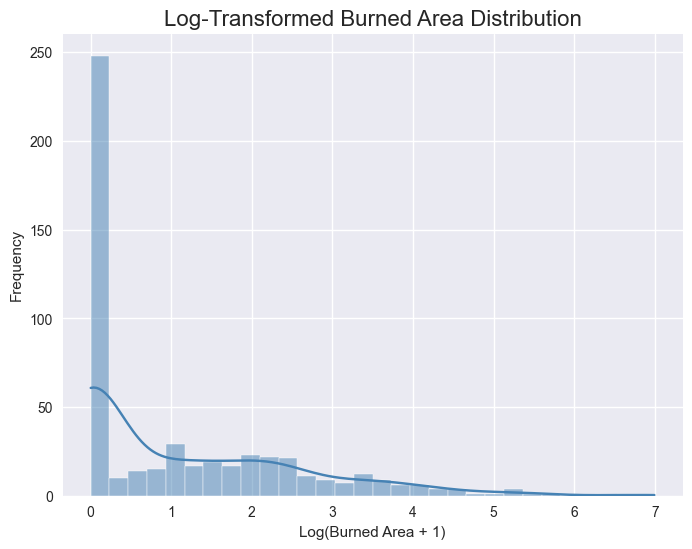

In [69]:
df["log_area"] = np.log1p(df["area"])

plt.figure(figsize=(8,6))

sns.histplot(
    df["log_area"],
    bins=30,
    kde=True,
    color="steelblue"
)

plt.title("Log-Transformed Burned Area Distribution", fontsize=16)
plt.xlabel("Log(Burned Area + 1)")
plt.ylabel("Frequency")

plt.show()

<div style="color:#60b9e5;">

## <h4>Insights:  
</h4> </div>

## <h2 style="color: #cb236f;">2. Numerical Feature Analysis</h2>

## <h4 style="color: #6b9c80;">- Correlation heatmap</h4>

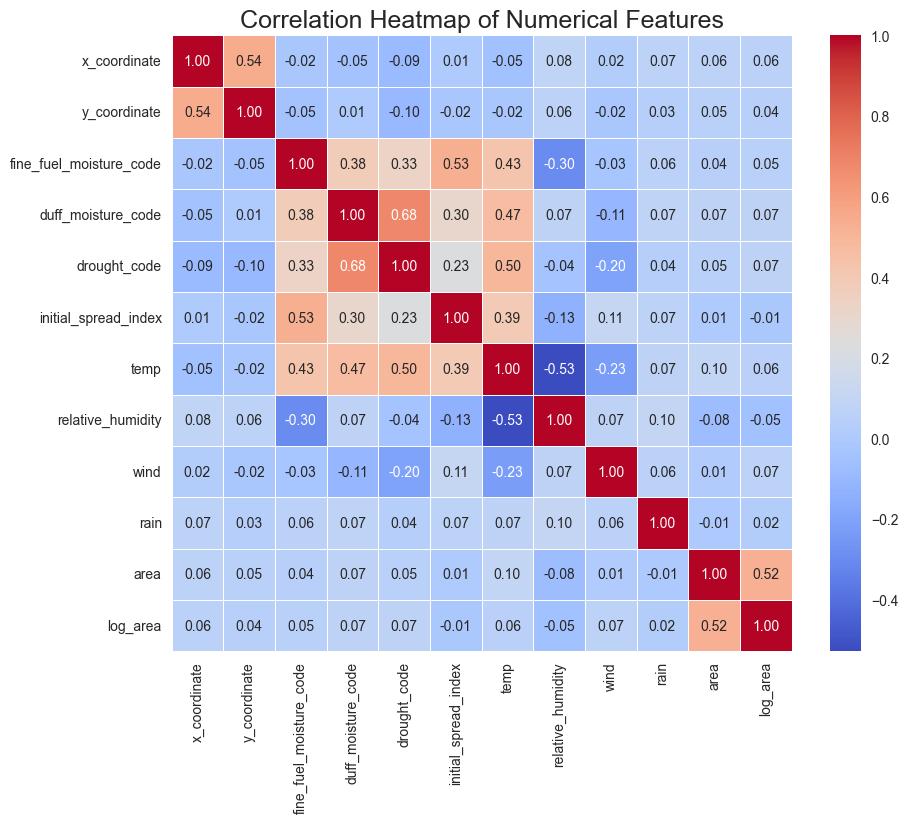

In [70]:
plt.figure(figsize=(10,8))

correlation_matrix = df.select_dtypes(include=['int64', 'float64']).corr()

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    linewidths=0.5,
    fmt=".2f"
)

plt.title("Correlation Heatmap of Numerical Features", fontsize=18)

plt.show()

<div style="color:#60b9e5;">

## <h4>Insights:  
</h4> </div>

## <h4 style="color: #6b9c80;">- Temperature vs Burned Area</h4>

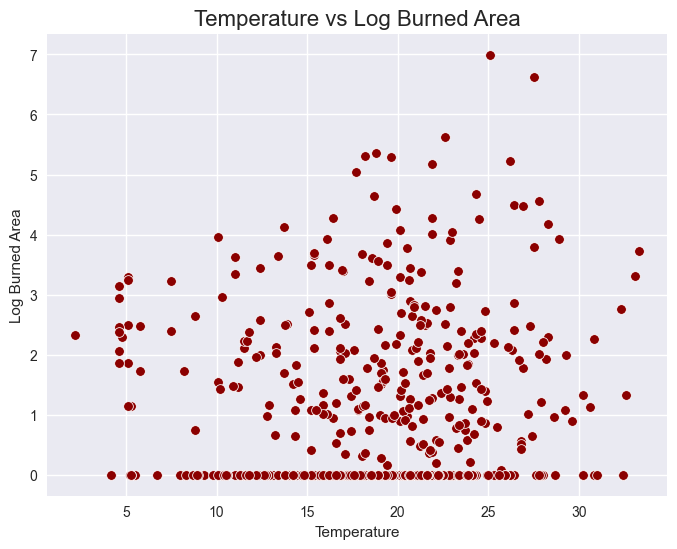

In [71]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x=df["temp"],
    y=df["log_area"],
    color="darkred"
)

plt.title("Temperature vs Log Burned Area", fontsize=16)
plt.xlabel("Temperature")
plt.ylabel("Log Burned Area")

plt.show()

<div style="color:#60b9e5;">

## <h4>Insights:  
</h4> </div>

## <h4 style="color: #6b9c80;">- Relative Humidity vs Burned Area</h4>

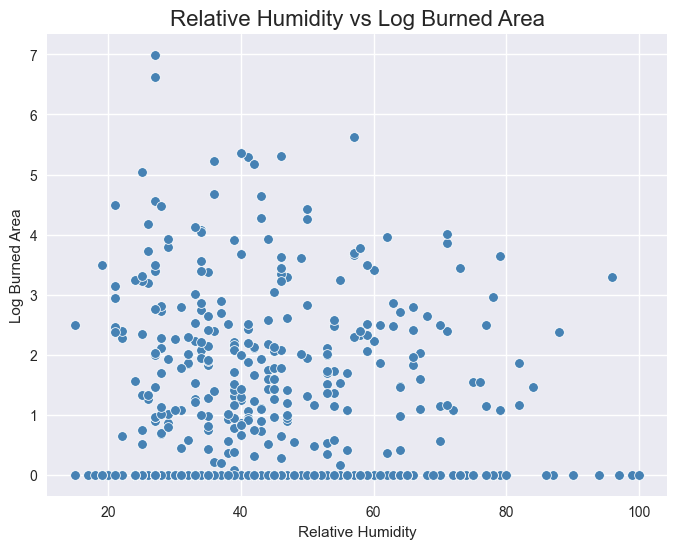

In [72]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x=df["relative_humidity"],
    y=df["log_area"],
    color="steelblue"
)

plt.title("Relative Humidity vs Log Burned Area", fontsize=16)
plt.xlabel("Relative Humidity")
plt.ylabel("Log Burned Area")

plt.show()

<div style="color:#60b9e5;">

## <h4>Insights: 
</h4> </div>

## <h4 style="color: #6b9c80;">- Wind vs Burned Area</h4>

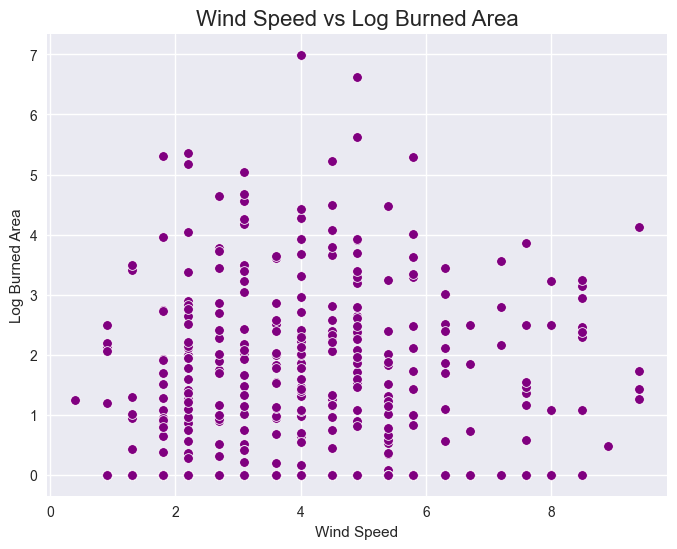

In [73]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x=df["wind"],
    y=df["log_area"],
    color="purple"
)

plt.title("Wind Speed vs Log Burned Area", fontsize=16)
plt.xlabel("Wind Speed")
plt.ylabel("Log Burned Area")

plt.show()

<div style="color:#60b9e5;">

## <h4>Insights: 
.</h4> </div>

## <h4 style="color: #6b9c80;">- Temperature Distribution by Month</h4>

/var/folders/y9/yzw2lv891kn9kfdx6qhrb39w0000gn/T/ipykernel_1913/4224471014.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


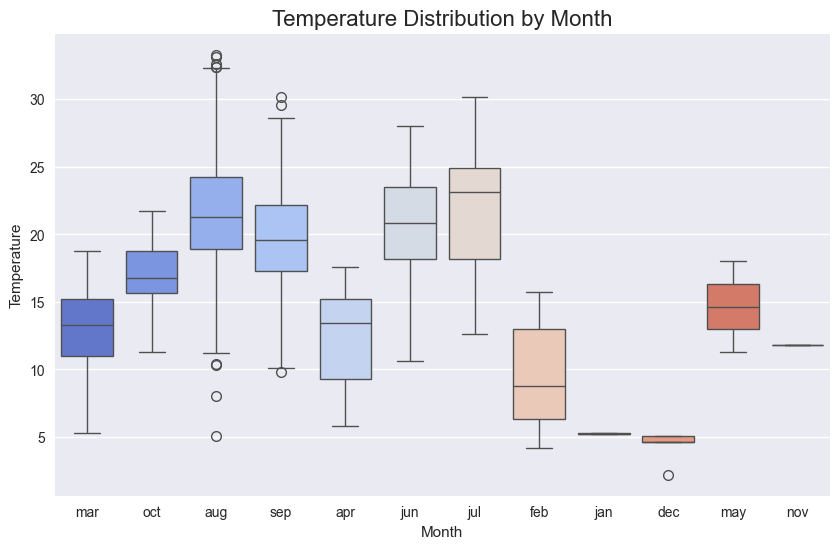

In [74]:
plt.figure(figsize=(10,6))

sns.boxplot(
    x=df["month"],
    y=df["temp"],
    palette="coolwarm"
)

plt.title("Temperature Distribution by Month", fontsize=16)
plt.xlabel("Month")
plt.ylabel("Temperature")

plt.show()

## <h4 style="color: #60b9e5;">Insights:</h4>

## <h4 style="color: #6b9c80;">- Feature relationship pair plot</h4>

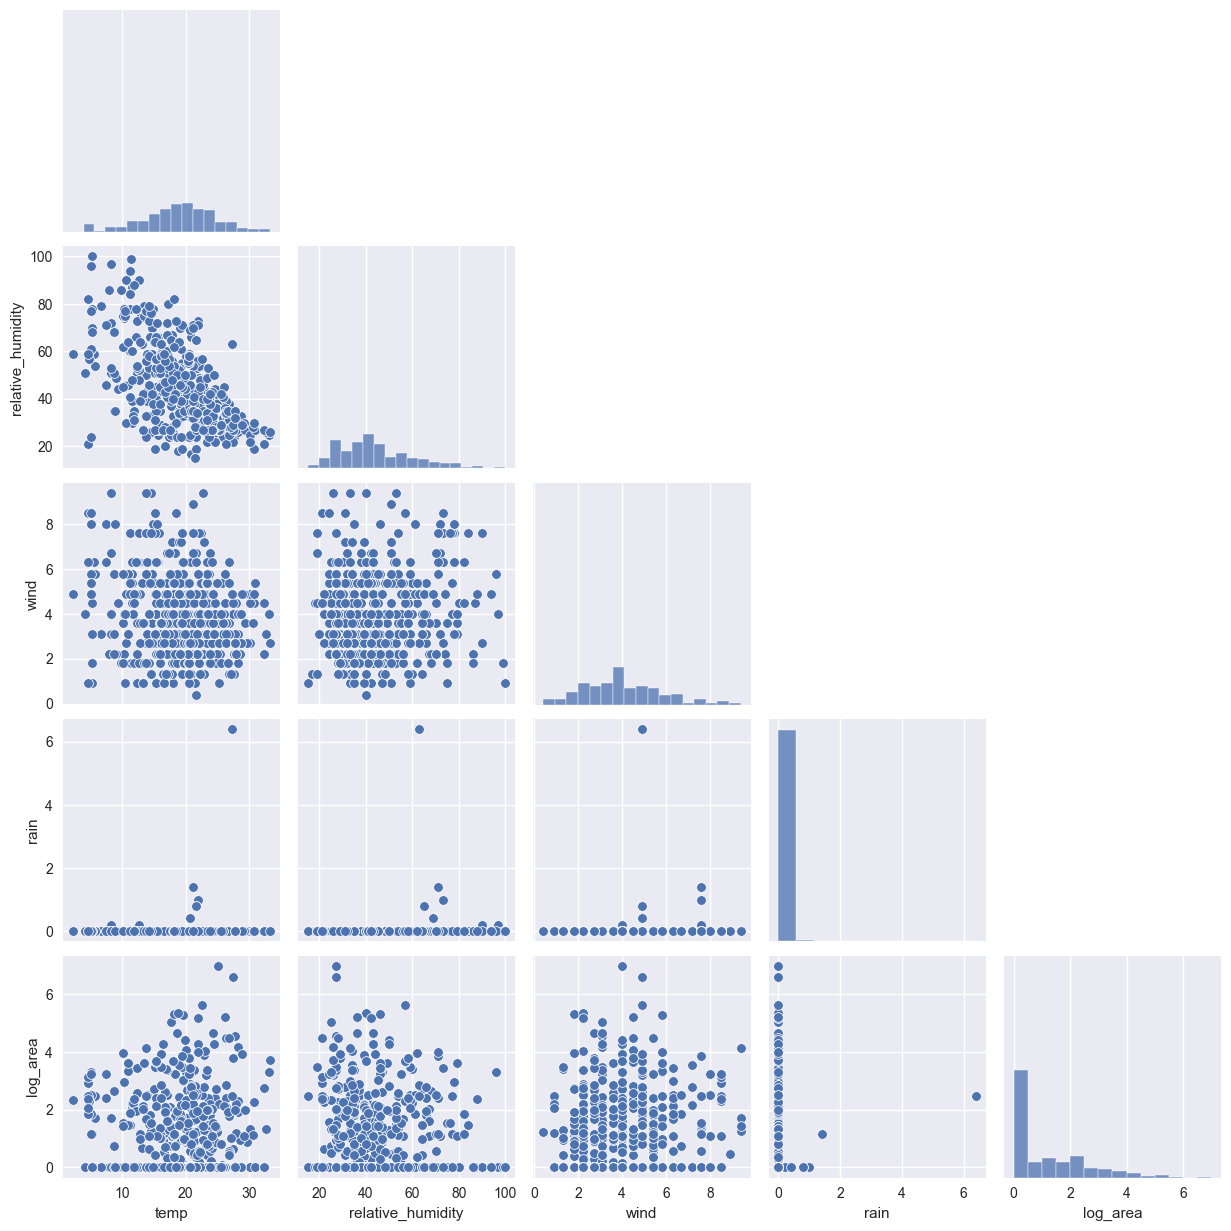

In [75]:
selected_features = [
    "temp",
    "relative_humidity",
    "wind",
    "rain",
    "log_area"
]

sns.pairplot(
    df[selected_features],
    corner=True
)

plt.show()

<div style="color:#60b9e5;">

## <h4>Insights:  
</h4> </div>

## <h2 style="color: #cb236f;">3. Categorical Feature Analysis</h2>

Goals: 
A.Which months experience the most wildfire activity?

B.Which days show higher fire frequency?

C.Are certain seasons more dangerous?

D.How do environmental conditions vary across months?

## <h4 style="color: #6b9c80;">- Wildfire Frequency by Month</h4>

/var/folders/y9/yzw2lv891kn9kfdx6qhrb39w0000gn/T/ipykernel_1913/2067466357.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


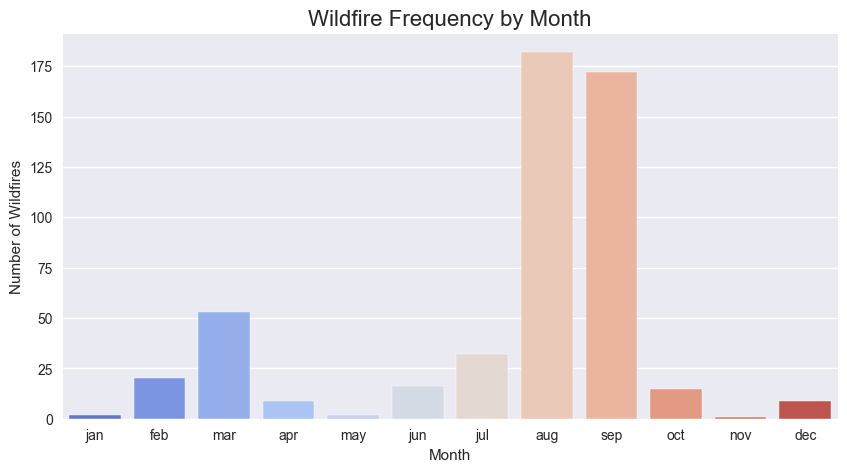

In [76]:
month_order = [
    "jan", "feb", "mar", "apr",
    "may", "jun", "jul", "aug",
    "sep", "oct", "nov", "dec"
]

plt.figure(figsize=(10,5))

sns.countplot(
    x=df["month"],
    order=month_order,
    palette="coolwarm"
)

plt.title("Wildfire Frequency by Month", fontsize=16)
plt.xlabel("Month")
plt.ylabel("Number of Wildfires")

plt.show()

## <h4 style="color: #60b9e5;">Insights: </h4>

## <h4 style="color: #6b9c80;">- Wildfire Frequency by Day</h4>

/var/folders/y9/yzw2lv891kn9kfdx6qhrb39w0000gn/T/ipykernel_1913/4098480691.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


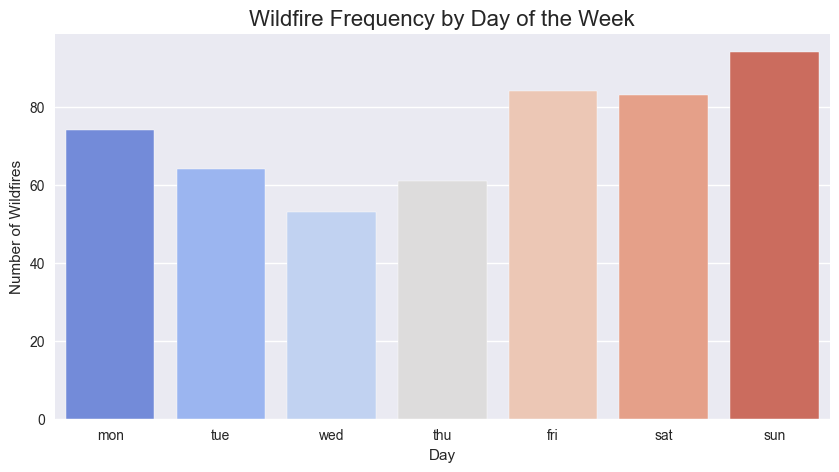

In [77]:
day_order = ["mon", "tue", "wed", "thu", "fri", "sat", "sun"]

plt.figure(figsize=(10,5))

sns.countplot(
    x=df["day"],
    order=day_order,
    palette="coolwarm"
)

plt.title("Wildfire Frequency by Day of the Week", fontsize=16)
plt.xlabel("Day")
plt.ylabel("Number of Wildfires")

plt.show()

## <h4 style="color: #60b9e5;">Insights: </h4>

## <h4 style="color: #6b9c80;">- Average Burned Area by Month</h4>

/var/folders/y9/yzw2lv891kn9kfdx6qhrb39w0000gn/T/ipykernel_1913/1263904379.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


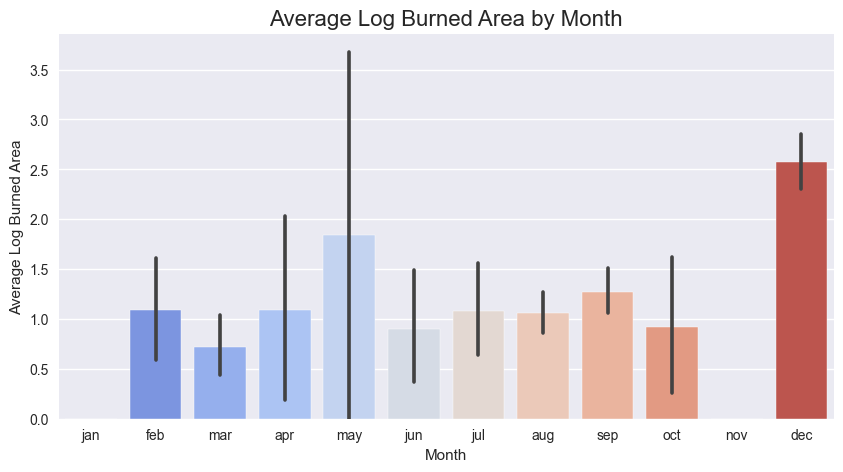

In [78]:
plt.figure(figsize=(10,5))

sns.barplot(
    x="month",
    y="log_area",
    data=df,
    order=month_order,
    palette="coolwarm"
)

plt.title("Average Log Burned Area by Month", fontsize=16)
plt.xlabel("Month")
plt.ylabel("Average Log Burned Area")

plt.show()

## <h4 style="color: #60b9e5;">Insights:  </h4>

## <h4 style="color: #6b9c80;">- Temperature Across Months</h4>

/var/folders/y9/yzw2lv891kn9kfdx6qhrb39w0000gn/T/ipykernel_1913/1515640573.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


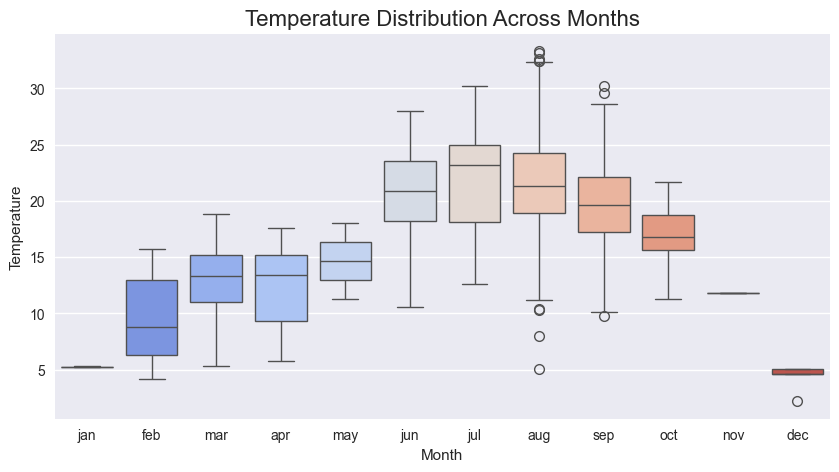

In [79]:
plt.figure(figsize=(10,5))

sns.boxplot(
    x="month",
    y="temp",
    data=df,
    order=month_order,
    palette="coolwarm"
)

plt.title("Temperature Distribution Across Months", fontsize=16)
plt.xlabel("Month")
plt.ylabel("Temperature")

plt.show()

## <h4 style="color: #60b9e5;">Insights:  </h4>

## <h4 style="color: #6b9c80;">- Relative Humidity Across Months</h4>

/var/folders/y9/yzw2lv891kn9kfdx6qhrb39w0000gn/T/ipykernel_1913/1128249536.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


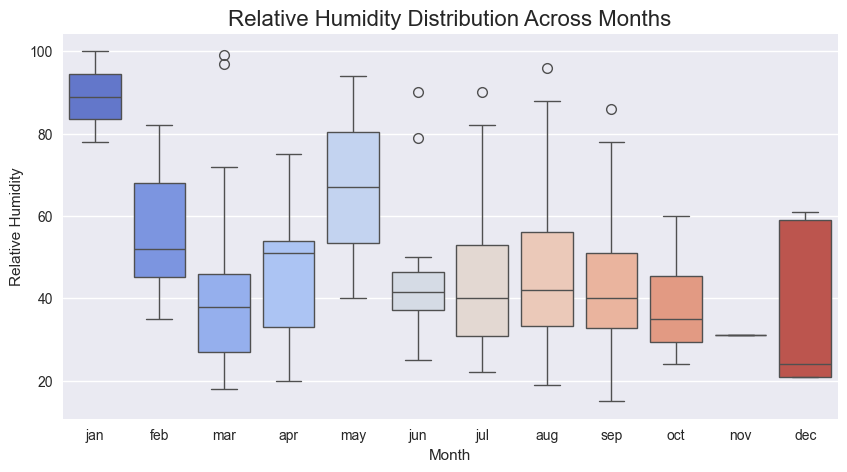

In [80]:
plt.figure(figsize=(10,5))

sns.boxplot(
    x="month",
    y="relative_humidity",
    data=df,
    order=month_order,
    palette="coolwarm"
)

plt.title("Relative Humidity Distribution Across Months", fontsize=16)
plt.xlabel("Month")
plt.ylabel("Relative Humidity")

plt.show()

## <h4 style="color: #60b9e5;">Insights: </h4>

## <h2 style="color: #cb236f;">4. Feature Engineering & Target Creation</h2>
Goals: 
A.Create wildfire risk categories

B.Engineer ML-ready target

C.Prepare categorical variables

D.Build modeling dataset

## <h4 style="color: #6b9c80;">— Log Transform Skewed Features</h4>

In [81]:
# Log transform highly skewed "wind"

df["log_wind"] = np.log1p(df["wind"])


## <h4 style="color: #6b9c80;">— Visualise Transformed Features</h4>

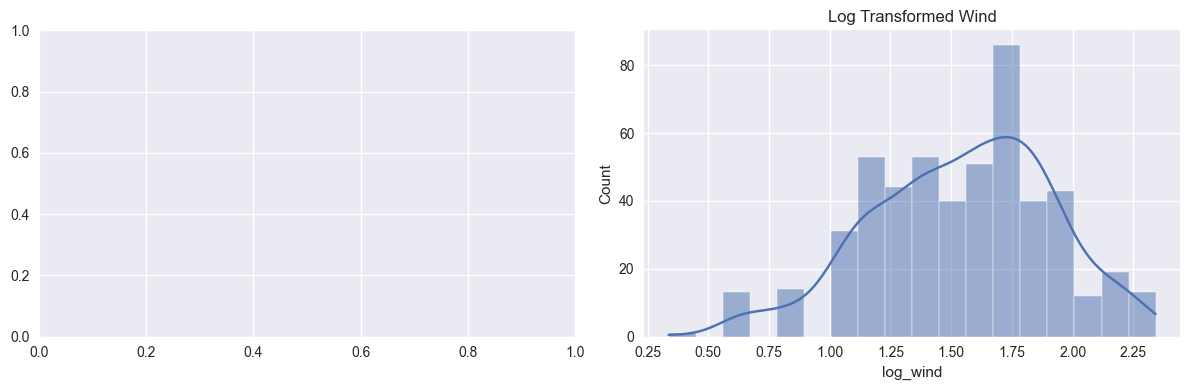

In [82]:
# Visualize transformed features
fig, axes = plt.subplots(1, 2, figsize=(12,4))

sns.histplot(df["log_wind"], kde=True, ax=axes[1])
axes[1].set_title("Log Transformed Wind")

plt.tight_layout()
plt.show()

## <h4 style="color: #6b9c80;">— Create Wildfire Risk Categories & examine class distributions</h4>
The original burned area variable is highly skewed and difficult to model directly using standard regression techniques. To improve interpretability and create a more practical machine learning problem, wildfire events were grouped into categorical wildfire risk levels based on burned area severity.

In [83]:
median_area = df["area"].median()

df["fire_severity_binary"] = np.where(
    df["area"] > median_area,
    "High Severity",
    "Low Severity"
)

# Check class distribution
print(df["fire_severity_binary"].value_counts())

print(
    df["fire_severity_binary"]
    .value_counts(normalize=True) * 100
)

fire_severity_binary
Low Severity     257
High Severity    256
Name: count, dtype: int64
fire_severity_binary
Low Severity     50.097466
High Severity    49.902534
Name: proportion, dtype: float64


In [84]:
#  Examine Class Distribution
counts = df["fire_severity_binary"].value_counts()

print("\nBinary Class Distribution:")
print(counts)


Binary Class Distribution:
fire_severity_binary
Low Severity     257
High Severity    256
Name: count, dtype: int64


In [85]:
# Percentage Distribution

binary_percentages = (
    df["fire_severity_binary"]
    .value_counts(normalize=True) * 100
)

print("Percentages:")
print(binary_percentages)

Percentages:
fire_severity_binary
Low Severity     50.097466
High Severity    49.902534
Name: proportion, dtype: float64


## <h4 style="color: #6b9c80;">— Visualize Risk Categories</h4>

/var/folders/y9/yzw2lv891kn9kfdx6qhrb39w0000gn/T/ipykernel_1913/3975498228.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


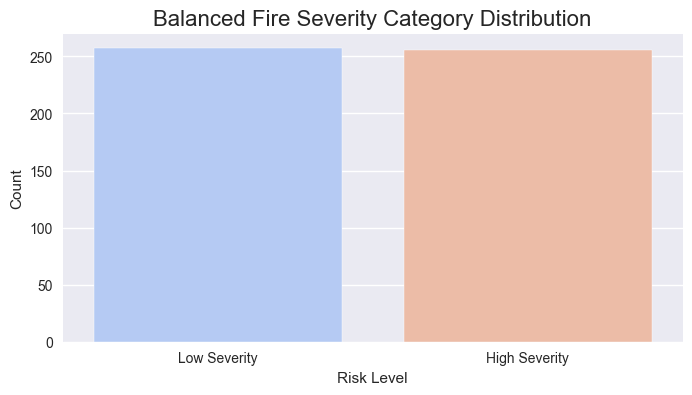

In [86]:
plt.figure(figsize=(8,4))

sns.countplot(
    x=df["fire_severity_binary"],
    palette="coolwarm",
    order=["Low Severity", "High Severity"]
)

plt.title("Balanced Fire Severity Category Distribution", fontsize=16)
plt.xlabel("Risk Level")
plt.ylabel("Count")

plt.show()

## <h4 style="color: #60b9e5;">Insights:  </h4>

## <h4 style="color: #6b9c80;">— Cyclical Encoding for Seasonality</h4>

In [87]:
# Convert month and day into numerical values

month_mapping = {
    "jan":1, "feb":2, "mar":3, "apr":4,
    "may":5, "jun":6, "jul":7, "aug":8,
    "sep":9, "oct":10, "nov":11, "dec":12
}

day_mapping = {
    "mon":1, "tue":2, "wed":3,
    "thu":4, "fri":5, "sat":6, "sun":7
}

df["month_num"] = df["month"].map(month_mapping)
df["day_num"] = df["day"].map(day_mapping)

# Cyclical encoding
df["month_sin"] = np.sin(2 * np.pi * df["month_num"] / 12)
df["month_cos"] = np.cos(2 * np.pi * df["month_num"] / 12)

df["day_sin"] = np.sin(2 * np.pi * df["day_num"] / 7)
df["day_cos"] = np.cos(2 * np.pi * df["day_num"] / 7)

display(df[[
    "month",
    "month_sin",
    "month_cos",
    "day",
    "day_sin",
    "day_cos"
]].head())

,month,month_sin,month_cos,day,day_sin,day_cos
0,mar,1.000000,6.123234e-17,fri,-9.749279e-01,-0.222521
1,oct,-0.866025,5.000000e-01,tue,9.749279e-01,-0.222521
2,oct,-0.866025,5.000000e-01,sat,-7.818315e-01,0.623490
3,mar,1.000000,6.123234e-17,fri,-9.749279e-01,-0.222521
4,mar,1.000000,6.123234e-17,sun,-2.449294e-16,1.000000


## <h4 style="color: #6b9c80;">— Keeping cyclical features</h4>


In [88]:
df_encoded = df.copy()

# Drop original categorical columns
df_encoded = df_encoded.drop(
    columns=["month", "day", "month_num", "day_num"]
)

## <h4 style="color: #6b9c80;">— Prepare Final Feature-Engineered Dataset</h4>

The original ⁠ month ⁠ and ⁠ day ⁠ columns are removed because they have already been converted into cyclical features using sine and cosine encoding.

This keeps the circular nature of time-based variables, for example December being close to January and Sunday being close to Monday.

## <h4 style="color: #6b9c80;">— Final leakage removal will happen in the modeling dataset section</h4>

In [94]:

print("Feature-engineered dataframe shape:", df_encoded.shape)
print("Columns in df_encoded:")
print(df_encoded.columns.tolist())

Feature-engineered dataframe shape: (513, 16)
Columns in df_encoded:
['x_coordinate', 'y_coordinate', 'fine_fuel_moisture_code', 'duff_moisture_code', 'drought_code', 'initial_spread_index', 'temp', 'relative_humidity', 'rain', 'log_area', 'log_wind', 'fire_severity_binary', 'month_sin', 'month_cos', 'day_sin', 'day_cos']


## <h4 style="color: #6b9c80;">— Define Modeling Features and Target</h4>

For classification modeling, ⁠ fire_severity_binary ⁠ is the target variable. The original ⁠ area ⁠ column and ⁠ log_area ⁠ column must be removed from the feature set because they directly describe burned area and would cause target leakage.

In [95]:
# Define classification target
target = "fire_severity_binary"

# Create modeling dataset from encoded dataframe
df_modeling = df_encoded.copy()

# Columns that should NOT be used as model features
columns_to_drop = [
    "area",        # direct source of target leakage
    "log_area",    # transformed burned area; also leakage
    "month",       # original categorical column
    "day",         # original categorical column
    "month_num",   # intermediate encoding column
    "day_num",     # intermediate encoding column
    "wind",        # replaced by log_wind
    "rain"         # do not want raw rain
]

# Drop only columns that exist
df_modeling = df_modeling.drop(
    columns=[col for col in columns_to_drop if col in df_modeling.columns]
)

# Separate features and target
X = df_modeling.drop(columns=[target])
y = df_modeling[target]

print("Modeling dataset shape:", df_modeling.shape)
print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)

display(X.head())
display(y.head())

Modeling dataset shape: (513, 14)
Feature matrix shape: (513, 13)
Target shape: (513,)


,x_coordinate,y_coordinate,fine_fuel_moisture_code,duff_moisture_code,drought_code,initial_spread_index,temp,relative_humidity,log_wind,month_sin,month_cos,day_sin,day_cos
0,7,5,86.2,26.2,94.3,5.1,8.2,51,2.041220,1.000000,6.123234e-17,-9.749279e-01,-0.222521
1,7,4,90.6,35.4,669.1,6.7,18.0,33,0.641854,-0.866025,5.000000e-01,9.749279e-01,-0.222521
2,7,4,90.6,43.7,686.9,6.7,14.6,33,0.832909,-0.866025,5.000000e-01,-7.818315e-01,0.623490
3,8,6,91.7,33.3,77.5,9.0,8.3,97,1.609438,1.000000,6.123234e-17,-9.749279e-01,-0.222521
4,8,6,89.3,51.3,102.2,9.6,11.4,99,1.029619,1.000000,6.123234e-17,-2.449294e-16,1.000000


0    Low Severity
1    Low Severity
2    Low Severity
3    Low Severity
4    Low Severity
Name: fire_severity_binary, dtype: object

## <h4 style="color: #6b9c80;">— Verify Final Dataset</h4>

In [96]:
print("Final Modeling Dataset Shape:", df_modeling.shape)
print("Feature Matrix Shape:", X.shape)
print("Target Shape:", y.shape)

print("\nFinal modeling columns:")
print(df_modeling.columns.tolist())

display(df_modeling.head())

Final Modeling Dataset Shape: (513, 14)
Feature Matrix Shape: (513, 13)
Target Shape: (513,)

Final modeling columns:
['x_coordinate', 'y_coordinate', 'fine_fuel_moisture_code', 'duff_moisture_code', 'drought_code', 'initial_spread_index', 'temp', 'relative_humidity', 'log_wind', 'fire_severity_binary', 'month_sin', 'month_cos', 'day_sin', 'day_cos']


,x_coordinate,y_coordinate,fine_fuel_moisture_code,duff_moisture_code,drought_code,initial_spread_index,temp,relative_humidity,log_wind,fire_severity_binary,month_sin,month_cos,day_sin,day_cos
0,7,5,86.2,26.2,94.3,5.1,8.2,51,2.041220,Low Severity,1.000000,6.123234e-17,-9.749279e-01,-0.222521
1,7,4,90.6,35.4,669.1,6.7,18.0,33,0.641854,Low Severity,-0.866025,5.000000e-01,9.749279e-01,-0.222521
2,7,4,90.6,43.7,686.9,6.7,14.6,33,0.832909,Low Severity,-0.866025,5.000000e-01,-7.818315e-01,0.623490
3,8,6,91.7,33.3,77.5,9.0,8.3,97,1.609438,Low Severity,1.000000,6.123234e-17,-9.749279e-01,-0.222521
4,8,6,89.3,51.3,102.2,9.6,11.4,99,1.029619,Low Severity,1.000000,6.123234e-17,-2.449294e-16,1.000000


In [98]:
# Check whether target accidentally exists inside features
print("Target in X:", "fire_severity_binary" in X.columns)

# Check for leakage columns
leakage_columns = ["area", "log_area", "fire_severity_binary"]

print("\nLeakage columns found in X:")
print([col for col in leakage_columns if col in X.columns])

Target in X: False

Leakage columns found in X:
[]


## <h4 style="color: #6b9c80;">— Save Feature-Engineered Dataset</h4>

In [100]:
df_modeling.to_csv(
    "../data/processed/forestfires_modeling_ready.csv",
    index=False
)

print("Feature-engineered dataset saved successfully.")

Feature-engineered dataset saved successfully.


## <h1 style="color: #c63b4b;">Notebook conclusion</h1>